In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras 
from sklearn.model_selection import train_test_split

In [2]:
img_row, img_col = 102, 136
x, y = [], []
DATA_PATH = './dataset/'
counter = 0
classes = os.listdir(DATA_PATH)

print(classes)

['Boot', 'Sandal', 'Shoe']


In [3]:
import keras.utils

for class_path in classes:
    for img_path in os.listdir(f"{DATA_PATH}{class_path}"):
        path = f"{DATA_PATH}{class_path}/{img_path}"
        label = counter
        image = tf.keras.preprocessing.image.load_img(path, target_size=(img_row, img_col))
        image = tf.keras.preprocessing.image.img_to_array(image)
        x.append(image)
        y.append(label)
    counter += 1

x = np.array(x)
y = np.array(y)
x = x.astype('float32') / 255.0

# 80 : 10 : 10
x_train, x_temp, y_train, y_temp = train_test_split(
    x, y, test_size=0.2, random_state=420
)

x_test, x_val, y_test, y_val = train_test_split(
    x_temp, y_temp, test_size=0.5, random_state=420
)

y_train = keras.utils.to_categorical(y_train)
y_test = keras.utils.to_categorical(y_test)
y_val = keras.utils.to_categorical(y_val)

print(x_train.shape)

(12000, 102, 136, 3)


In [4]:
import keras.layers

model = keras.Sequential()

model.add(keras.layers.Conv2D(6, (5, 5), activation = "relu", input_shape = (img_row, img_col, 3)))
model.add(keras.layers.AveragePooling2D(pool_size=(2,2), strides=2))
model.add(keras.layers.Conv2D(16, (5,5), activation="relu"))
model.add(keras.layers.AveragePooling2D(pool_size=(2,2), strides=2))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(120, activation="relu"))
model.add(keras.layers.Dense(84, activation="relu"))
model.add(keras.layers.Dense(3, activation="softmax"))

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 98, 132, 6)        456       
                                                                 
 average_pooling2d (AverageP  (None, 49, 66, 6)        0         
 ooling2D)                                                       
                                                                 
 conv2d_1 (Conv2D)           (None, 45, 62, 16)        2416      
                                                                 
 average_pooling2d_1 (Averag  (None, 22, 31, 16)       0         
 ePooling2D)                                                     
                                                                 
 flatten (Flatten)           (None, 10912)             0         
                                                                 
 dense (Dense)               (None, 120)               1

In [5]:
model.compile(
    optimizer="adam", 
    loss="categorical_crossentropy", 
    metrics=["Accuracy"]
)
history = model.fit(
    x_train, y_train, 
    epochs=10, batch_size=120, validation_data=(x_val, y_val)
)

Epoch 1/10
100/100 [==============================] - 4s 19ms/step - loss: 0.4336 - Accuracy: 0.8226 - val_loss: 0.2098 - val_Accuracy: 0.9260
Epoch 2/10
100/100 [==============================] - 2s 16ms/step - loss: 0.2049 - Accuracy: 0.9230 - val_loss: 0.1632 - val_Accuracy: 0.9400
Epoch 3/10
100/100 [==============================] - 2s 16ms/step - loss: 0.1467 - Accuracy: 0.9482 - val_loss: 0.1354 - val_Accuracy: 0.9533
Epoch 4/10
100/100 [==============================] - 2s 16ms/step - loss: 0.1042 - Accuracy: 0.9644 - val_loss: 0.1065 - val_Accuracy: 0.9667
Epoch 5/10
100/100 [==============================] - 2s 16ms/step - loss: 0.0827 - Accuracy: 0.9714 - val_loss: 0.0888 - val_Accuracy: 0.9673
Epoch 6/10
100/100 [==============================] - 2s 16ms/step - loss: 0.0522 - Accuracy: 0.9814 - val_loss: 0.0918 - val_Accuracy: 0.9660
Epoch 7/10
100/100 [==============================] - 2s 16ms/step - loss: 0.0389 - Accuracy: 0.9875 - val_loss: 0.0903 - val_Accuracy: 0.9693

In [7]:
model.evaluate(x_test, y_test)

47/47 [==============================] - 0s 4ms/step - loss: 0.1994 - Accuracy: 0.9473


[0.19943967461585999, 0.9473333358764648]

47/47 [==============================] - 0s 3ms/step


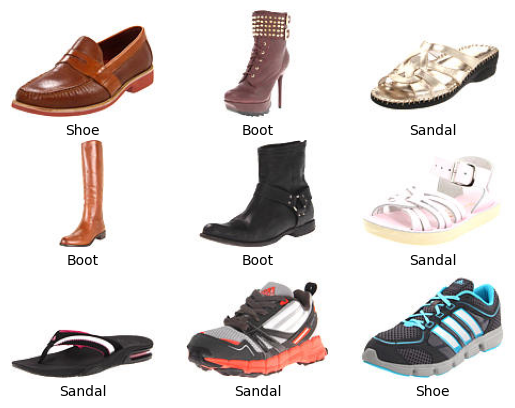

In [ ]:
prediction = model.predict(x_test)
predicted_label = np.argmax(prediction, axis=1)

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.axis('off')
    plt.text(
        0.5, -0.15, 
        classes[predicted_label[i]], fontsize=10, ha="center", 
        transform=plt.gca().transAxes
    )

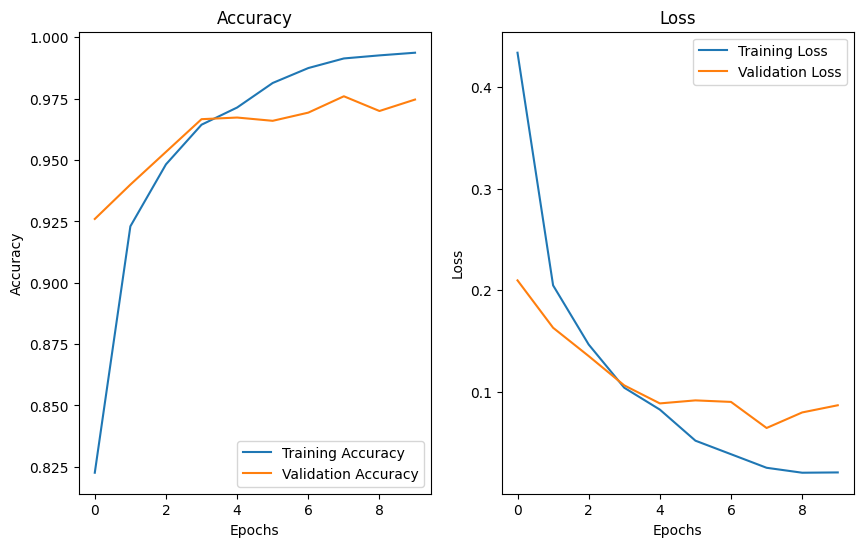

In [ ]:
plt.figure(figsize=(10, 6))

plt.subplot(1,2,1)
plt.plot(history.history["Accuracy"], label="Training Accuracy")
plt.plot(history.history["val_Accuracy"], label = "Validation Accuracy")
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label = "Validation Loss")
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()